## TD N°2 explicabilité du dataset Boston Housing

1) Charger le dataset bostong_housing
   1) Disponible dans le folder 04_interpretable_ml/td/data/
   
2) Nettoyer votre jeu de données pour créer une régression linéaire et un random forest
   1) Tester d'ajouter des features log, quadratique, ...

3)Créer un modèle baseline linéaire et random forest

4) Interpréter le modèle linéaire

5) Tuner votre random forest

6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

6) Réaliser une explicabilité par individu
   1) En utilisant la méthode ICE (PDP individuelle)
   2) LIME (Model local pour expliquer une prédiction)
   3) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

## Contexte du Dataset

Le Boston Housing Dataset est un ensemble de données couramment utilisé en apprentissage automatique et en statistique pour étudier les relations entre diverses caractéristiques socio-économiques et immobilières dans la ville de Boston.  
Il contient des informations sur des propriétés résidentielles et leur environnement, et est souvent utilisé pour prédire la valeur des maisons, un problème classique de régression.

**Variable dispo**: 
- CRIM : taux de criminalité par habitant par ville
- ZN : proportion de terrains résidentiels zonés pour des lots de plus de 25 000 pieds carrés
- INDUS : proportion de terrains commerciaux non commerciaux par ville
- CHAS : variable binaire indiquant la proximité de la rivière Charles (= 1 si la zone délimitée par la ville touche la rivière ; 0 sinon)
- NOX : concentration des oxydes d'azote (en parties par 10 millions)
- RM : nombre moyen de pièces par logement
- AGE : proportion des unités occupées par leur propriétaire et construites avant 1940
- DIS : distances pondérées vers cinq centres d'emploi de Boston
- RAD : indice d'accessibilité aux autoroutes radiales
- TAX : taux d'imposition foncière par valeur totale pour chaque tranche de 10 000 dollars
- PTRATIO : ratio élèves-enseignants par ville
- LSTAT : pourcentage de la population de statut socio-économique inférieur
- MEDV : valeur médiane des maisons occupées par leur propriétaire (en milliers de dollars) - **variable cible**

In [1]:
#Web request
import requests
import io
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay
import warnings
import shap
from alibi.explainers import ALE, plot_ale
from lime import lime_tabular

### 1) Charger le dataset bostong_housing

In [2]:
#Télécharge directement depuis Github
url = "https://raw.githubusercontent.com/Roulitoo/cours_iae/master/04_INTERPRETABLE_ML/td/data/boston_housing.csv" 
download = requests.get(url).content

df = pd.read_csv(io.StringIO(download.decode('utf-8')), sep=';')

### 2)Nettoyer votre jeu de données pour créer une régression linéaire et un random forest

Penser à :

- Vérifier comment encoder vos variables qualitatives pour la modélisation 
- Analyser les distributions
- Analyser les outliers 
- Analyser les corrélations

>Tester d'ajouter des features log, quadratique, ...

In [3]:
df.head(5)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


In [4]:
#Types des variables 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    int64  
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    int64  
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
#Transformer les variables CHAD et RAD en category
df['CHAS'] = df['CHAS'].astype('category')
df['RAD'] = df['RAD'].astype('category')

In [6]:
#Détecter les valeurs manquantes
if df.isnull().values.any():
    print("\nLe DataFrame contient des valeurs manquantes.")
else:
    print("\nAucune valeur manquante dans le DataFrame.")


Aucune valeur manquante dans le DataFrame.


In [7]:
df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,37.970000,50.000000


In [8]:
# On supprime la variable Unnamed: 0
df = df.drop(columns='Unnamed: 0')

In [9]:
# Détection des outliers

# Sélectionner les colonnes numériques (en excluant celles que vous ne voulez pas)
cols_to_normalize = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

# Appliquer la normalisation
#df[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

# Création du graphique boxplot
fig = go.Figure()

# Ajouter les boxplots pour chaque colonne normalisée
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col not in ['hospital_number', 'lesion_1', 'lesion_2', 'lesion_3']:
        fig.add_trace(go.Box(y=df[col], name=col, showlegend=False))  # Pas de légende

fig.update_layout(
    title_text="Distribution des variables quantitatives normalisées",
    height=800,
    width=1200
)

fig.show()

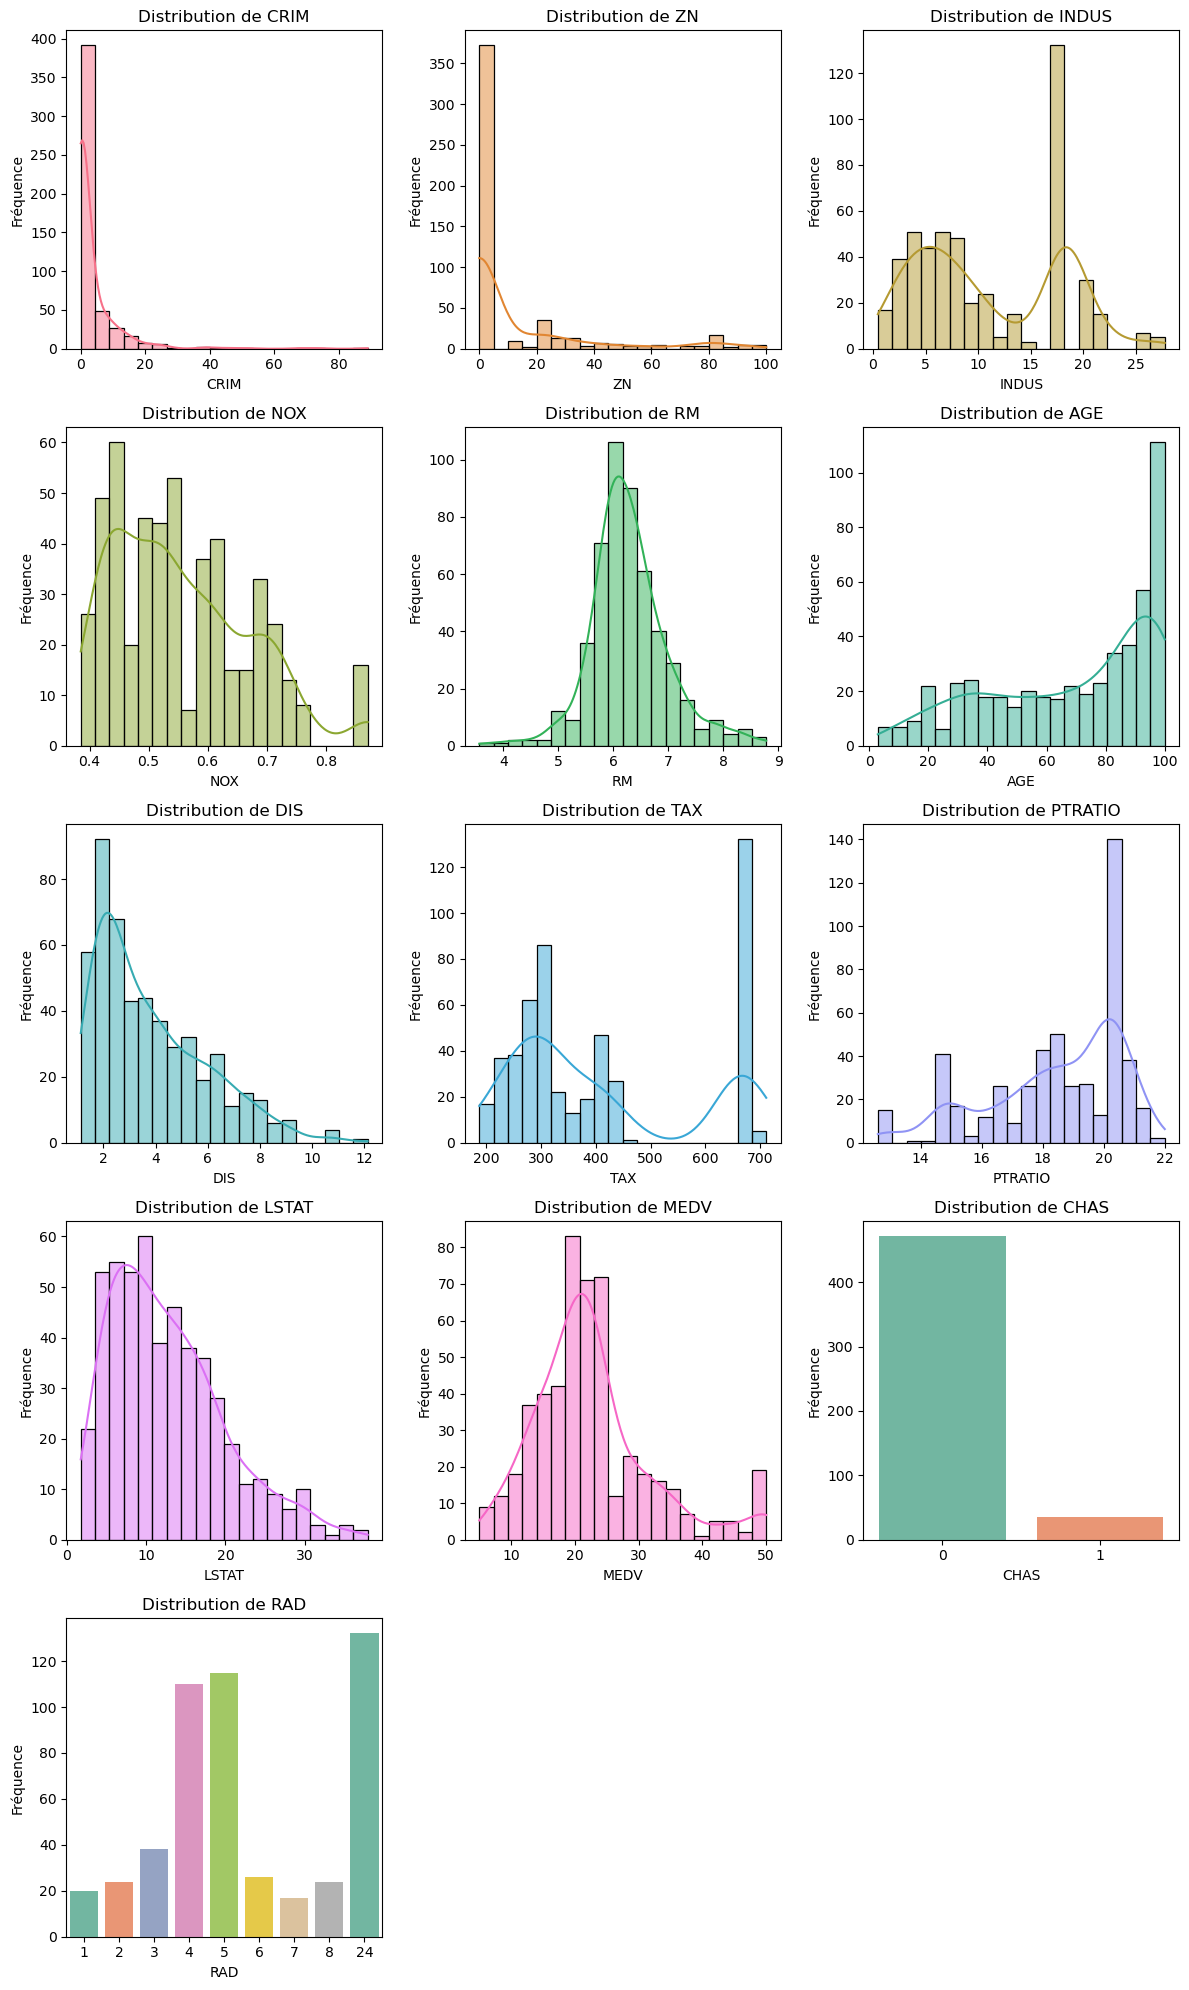

In [10]:
# Histogrammes - Distribution des variables quantitatives

# Sélection des colonnes numériques et catégorielles
quantitative_columns = df.select_dtypes(include=['float64']).columns
categorical_columns = ['CHAS', 'RAD']  # Ajouter les variables binaire et à plusieurs modalités

# Paramètres pour les sous-graphiques
num_vars = len(quantitative_columns)
cols = 3  # Nombre de colonnes de sous-graphiques
rows = (num_vars + len(categorical_columns) + cols - 1) // cols  # Calcul du nombre de lignes
colors = sns.color_palette("husl", num_vars)  # Palette de couleurs pour les histogrammes

# Création des sous-graphiques
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  # Aplatir les axes pour les itérer facilement

# Affichage des graphiques pour les variables quantitatives
for i, column in enumerate(quantitative_columns):
    sns.histplot(df[column], kde=True, bins=20, color=colors[i], ax=axes[i])
    axes[i].set_title(f'Distribution de {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Fréquence')

# Affichage des graphiques pour les variables catégorielles
for j, column in enumerate(categorical_columns):
    ax = axes[i + j + 1]  # Trouver un axe libre après les graphiques quantitatifs
    sns.countplot(x=df[column], ax=ax, palette='Set2')
    ax.set_title(f'Distribution de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Fréquence')

# Supprimer les axes inutilisés si le nombre de variables est impair
for k in range(i + j + 2, len(axes)):
    fig.delaxes(axes[k])

# Ajuster les espaces entre les graphiques
plt.tight_layout()
plt.show()


/var/folders/xj/s_btb6pn12s9qwlshk531wth0000gn/T/ipykernel_79158/270756393.py:3: FutureWarning:

The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.



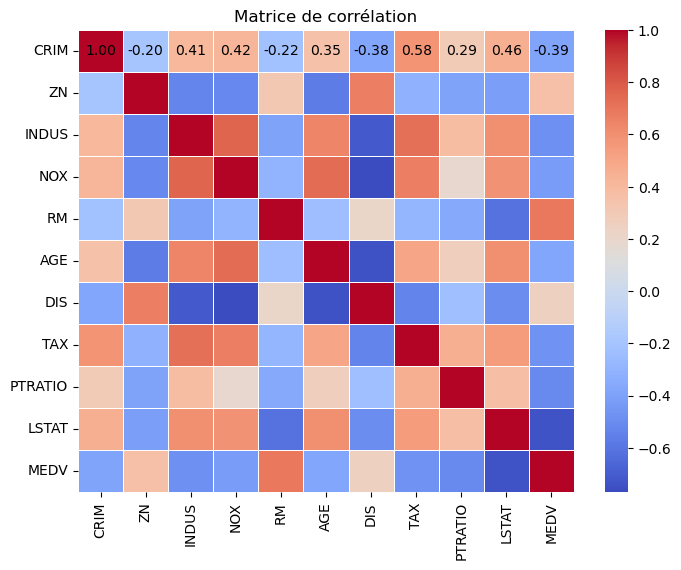

In [11]:
# Matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"color": "black"})
plt.title("Matrice de corrélation")
plt.show()

In [12]:
# Encodage de la variable catégorielle "RAD" avec LabelEncoder
label_encoder = LabelEncoder()

df['RAD_encoded'] = label_encoder.fit_transform(df['RAD'])

# Supprimer les colonnes originales
df = df.drop(columns=['RAD'])

In [13]:
print(df.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622  222.0     18.7   

   LSTAT  MEDV  RAD_encoded  
0   4.98  24.0            0  
1   9.14  21.6            1  
2   4.03  34.7            1  
3   2.94  33.4            2  
4   5.33  36.2            2  


### 3)Créer 2 modèles baseline, linéaire et random forest

In [14]:
#Séparer la base en 2 jeux de données¶ 
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Initialiser le StandardScaler
scaler = StandardScaler()

# Appliquer la standardisation sur l'ensemble complet des données avant la séparation
X_scaled = scaler.fit_transform(X)

# Séparer la base en jeux d'entraînement et de test (30% pour test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#### Modèle de régression linéaire

In [15]:
# Modèle de régression linéaire
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred_linear = linear_model.predict(X_test)

# Évaluation du modèle linéaire
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

# Affichage des résultats
print("Évaluation du modèle de régression linéaire :")
print(f"MSE : {mse_linear:.2f}")
print(f"R² : {r2_linear:.2f}")

Évaluation du modèle de régression linéaire :
MSE : 21.71
R² : 0.71


#### Modèle Random Forest

In [16]:
# Modèle Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred_rf = rf.predict(X_test)

# Évaluation du modèle Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Affichage des résultats
print("\nÉvaluation du modèle Random Forest :")
print(f"MSE : {mse_rf:.2f}")
print(f"R² : {r2_rf:.2f}")


Évaluation du modèle Random Forest :
MSE : 9.64
R² : 0.87


### 4) Interpréter le modèle linéaire
Utiliser les méthodes intrinsèques du modèle pour l'interprétation

In [17]:
import statsmodels.api as sm

# Ajouter une constante pour l'intercept
X_train_with_intercept = sm.add_constant(X_train)

# Créer et ajuster le modèle avec statsmodels
model_sm = sm.OLS(y_train, X_train_with_intercept).fit()

# Afficher le résumé du modèle
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     77.80
Date:                Wed, 05 Mar 2025   Prob (F-statistic):           6.57e-90
Time:                        20:26:56   Log-Likelihood:                -1061.2
No. Observations:                 354   AIC:                             2148.
Df Residuals:                     341   BIC:                             2199.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.5431      0.264     85.405      0.0

In [18]:
print(df.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV', 'RAD_encoded'],
      dtype='object')


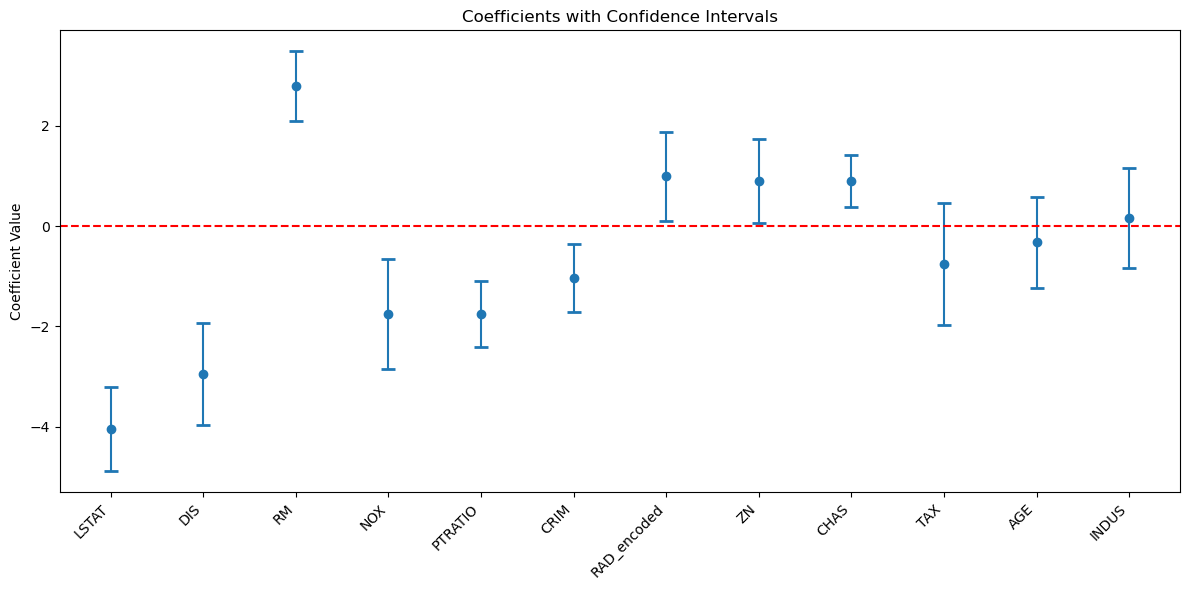

In [19]:
# Visualisation de l'impact de chaque variable sur le prix de l'immobilier
coef_df = pd.DataFrame({
    'Variable': ['Intercept'] + list(X.columns),
    'Coefficient': model_sm.params,
    'Std Error': model_sm.bse,
    'P-value': model_sm.pvalues,
    'Lower CI (0.025)': model_sm.conf_int()[0],
    'Upper CI (0.975)': model_sm.conf_int()[1]
})

# Sort by absolute coefficient value (excluding intercept)
coef_df_sorted = coef_df.iloc[1:].copy()
coef_df_sorted['Abs_Coefficient'] = np.abs(coef_df_sorted['Coefficient'])
coef_df_sorted = coef_df_sorted.sort_values('Abs_Coefficient', ascending=False)

# Visualization
plt.figure(figsize=(12, 6))
plt.title('Coefficients with Confidence Intervals')
plt.errorbar(coef_df_sorted['Variable'], coef_df_sorted['Coefficient'], 
             yerr=[coef_df_sorted['Coefficient']-coef_df_sorted['Lower CI (0.025)'], 
                   coef_df_sorted['Upper CI (0.975)']-coef_df_sorted['Coefficient']],
             fmt='o', capsize=5, capthick=2)
plt.axhline(y=0, color='r', linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

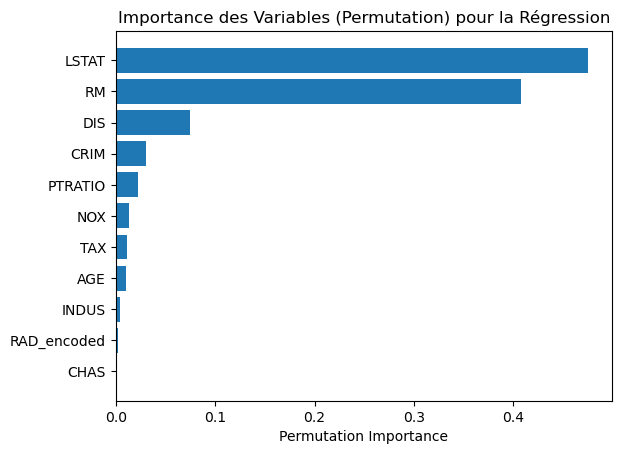

In [20]:
# Calcul de l'importance des variables pour un arbre de régression
perm_importance = permutation_importance(rf, 
                                         X_test, y_test,
                                         n_repeats=10,
                                         random_state=42,
                                         n_jobs=-1)

# Tri des indices des importances par ordre décroissant
sorted_idx = perm_importance.importances_mean.argsort()

# Filtrage des variables dont l'importance est supérieure à 0
filtered_idx = sorted_idx[perm_importance.importances_mean[sorted_idx] > 0]

# Récupérer les noms des colonnes depuis le DataFrame d'origine X
columns_filtered = X.columns[filtered_idx]

# Affichage de l'importance des variables via permutation (seulement celles > 0)
plt.barh(columns_filtered, perm_importance.importances_mean[filtered_idx])
plt.xlabel("Permutation Importance")
plt.title("Importance des Variables (Permutation) pour la Régression")
plt.show()


### 5) Tuner votre random forest

In [21]:
# Définition de la grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Création du modèle de base
rf = RandomForestRegressor(random_state=42)

# Création et exécution du GridSearchCV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("Meilleurs paramètres trouvés :")
print(grid_search.best_params_)

# Évaluation du modèle optimisé
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcul des métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nRésultats avec les meilleurs paramètres :")
print("Score R^2 :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Meilleurs paramètres trouvés :
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Résultats avec les meilleurs paramètres :
Score R^2 : 0.870569362512362
MAE : 2.061473684210527
RMSE : 3.1055237014916366


### 6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

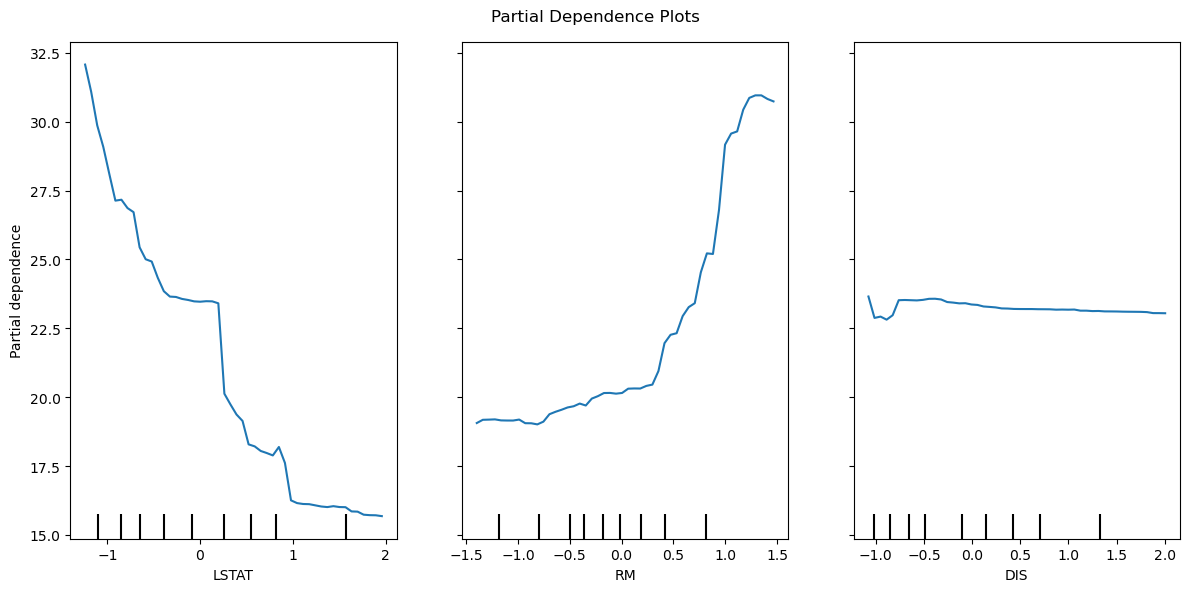

In [22]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

training_features = df.drop(columns=['MEDV']).columns
df_interpret = pd.DataFrame(X_test, columns = training_features)

# PDP pour plusieurs caractéristiques (par exemple, 'sepal length' et 'petal width')
features = ["LSTAT", "RM", "DIS"]  # Index des caractéristiques
_, ax1 = plt.subplots(figsize = (12,6))
PartialDependenceDisplay.from_estimator(best_rf,  #votre modèle
                                         df_interpret, 
                                         features,
                                         kind="average",
                                         ax = ax1,
                                         grid_resolution=50, # Nombre de points estimés pour le tracer de la courbe
                                         n_cols=3
                                         )
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

# Restaurer le comportement par défaut des avertissements
warnings.filterwarnings("default")

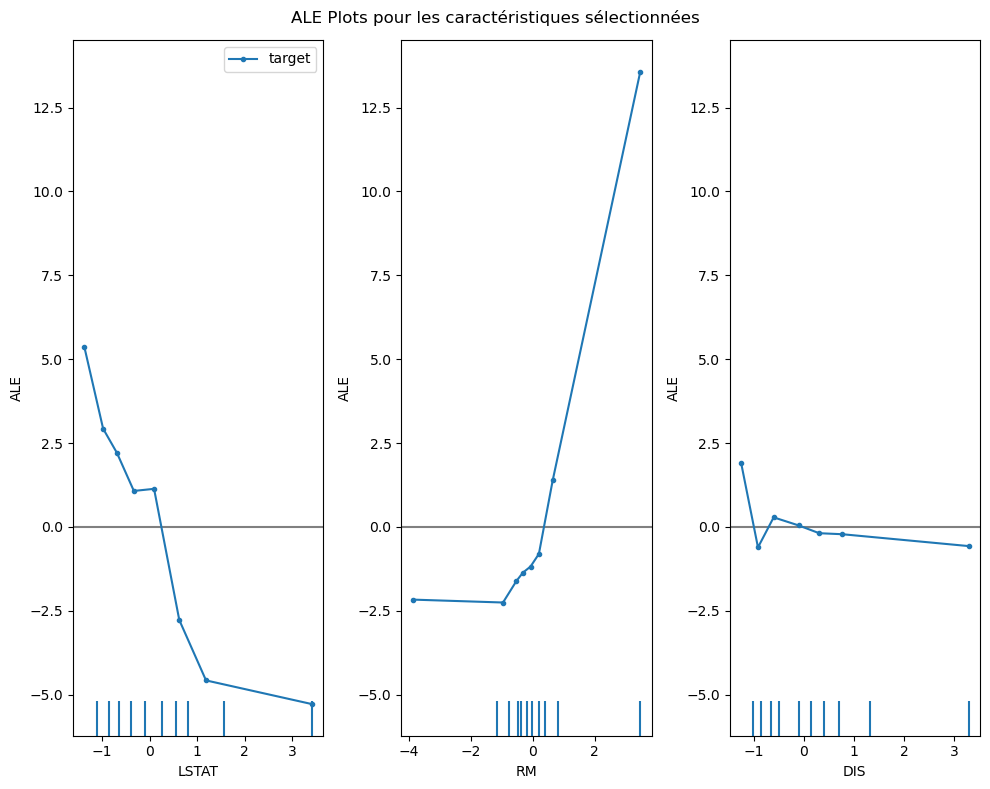

In [23]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

# Créer l'explainer ALE pour le modèle de régression logistique
logistic_ale = ALE(best_rf.predict, feature_names=training_features, target_names=["target"])

# Expliquer les données d'entraînement
logistic_exp = logistic_ale.explain(X_test, min_bin_points=20)

# Tracer les ALE plots pour les caractéristiques sélectionnées
_, ax1 = plt.subplots(figsize=(10, 8))
plot_ale(logistic_exp, features=["LSTAT", "RM", "DIS"], ax=ax1, targets=[0])
plt.suptitle("ALE Plots pour les caractéristiques sélectionnées")
plt.tight_layout()
plt.show()

# Restaurer le comportement par défaut des avertissements
warnings.filterwarnings("default")


### 7) Réaliser une explicabilité par individu
- A) En utilisant la méthode ICE (PDP individuelle)
- B) LIME (Model local pour expliquer une prédiction)
- C) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

#### A) En utilisant la méthode ICE (PDP individuelle)

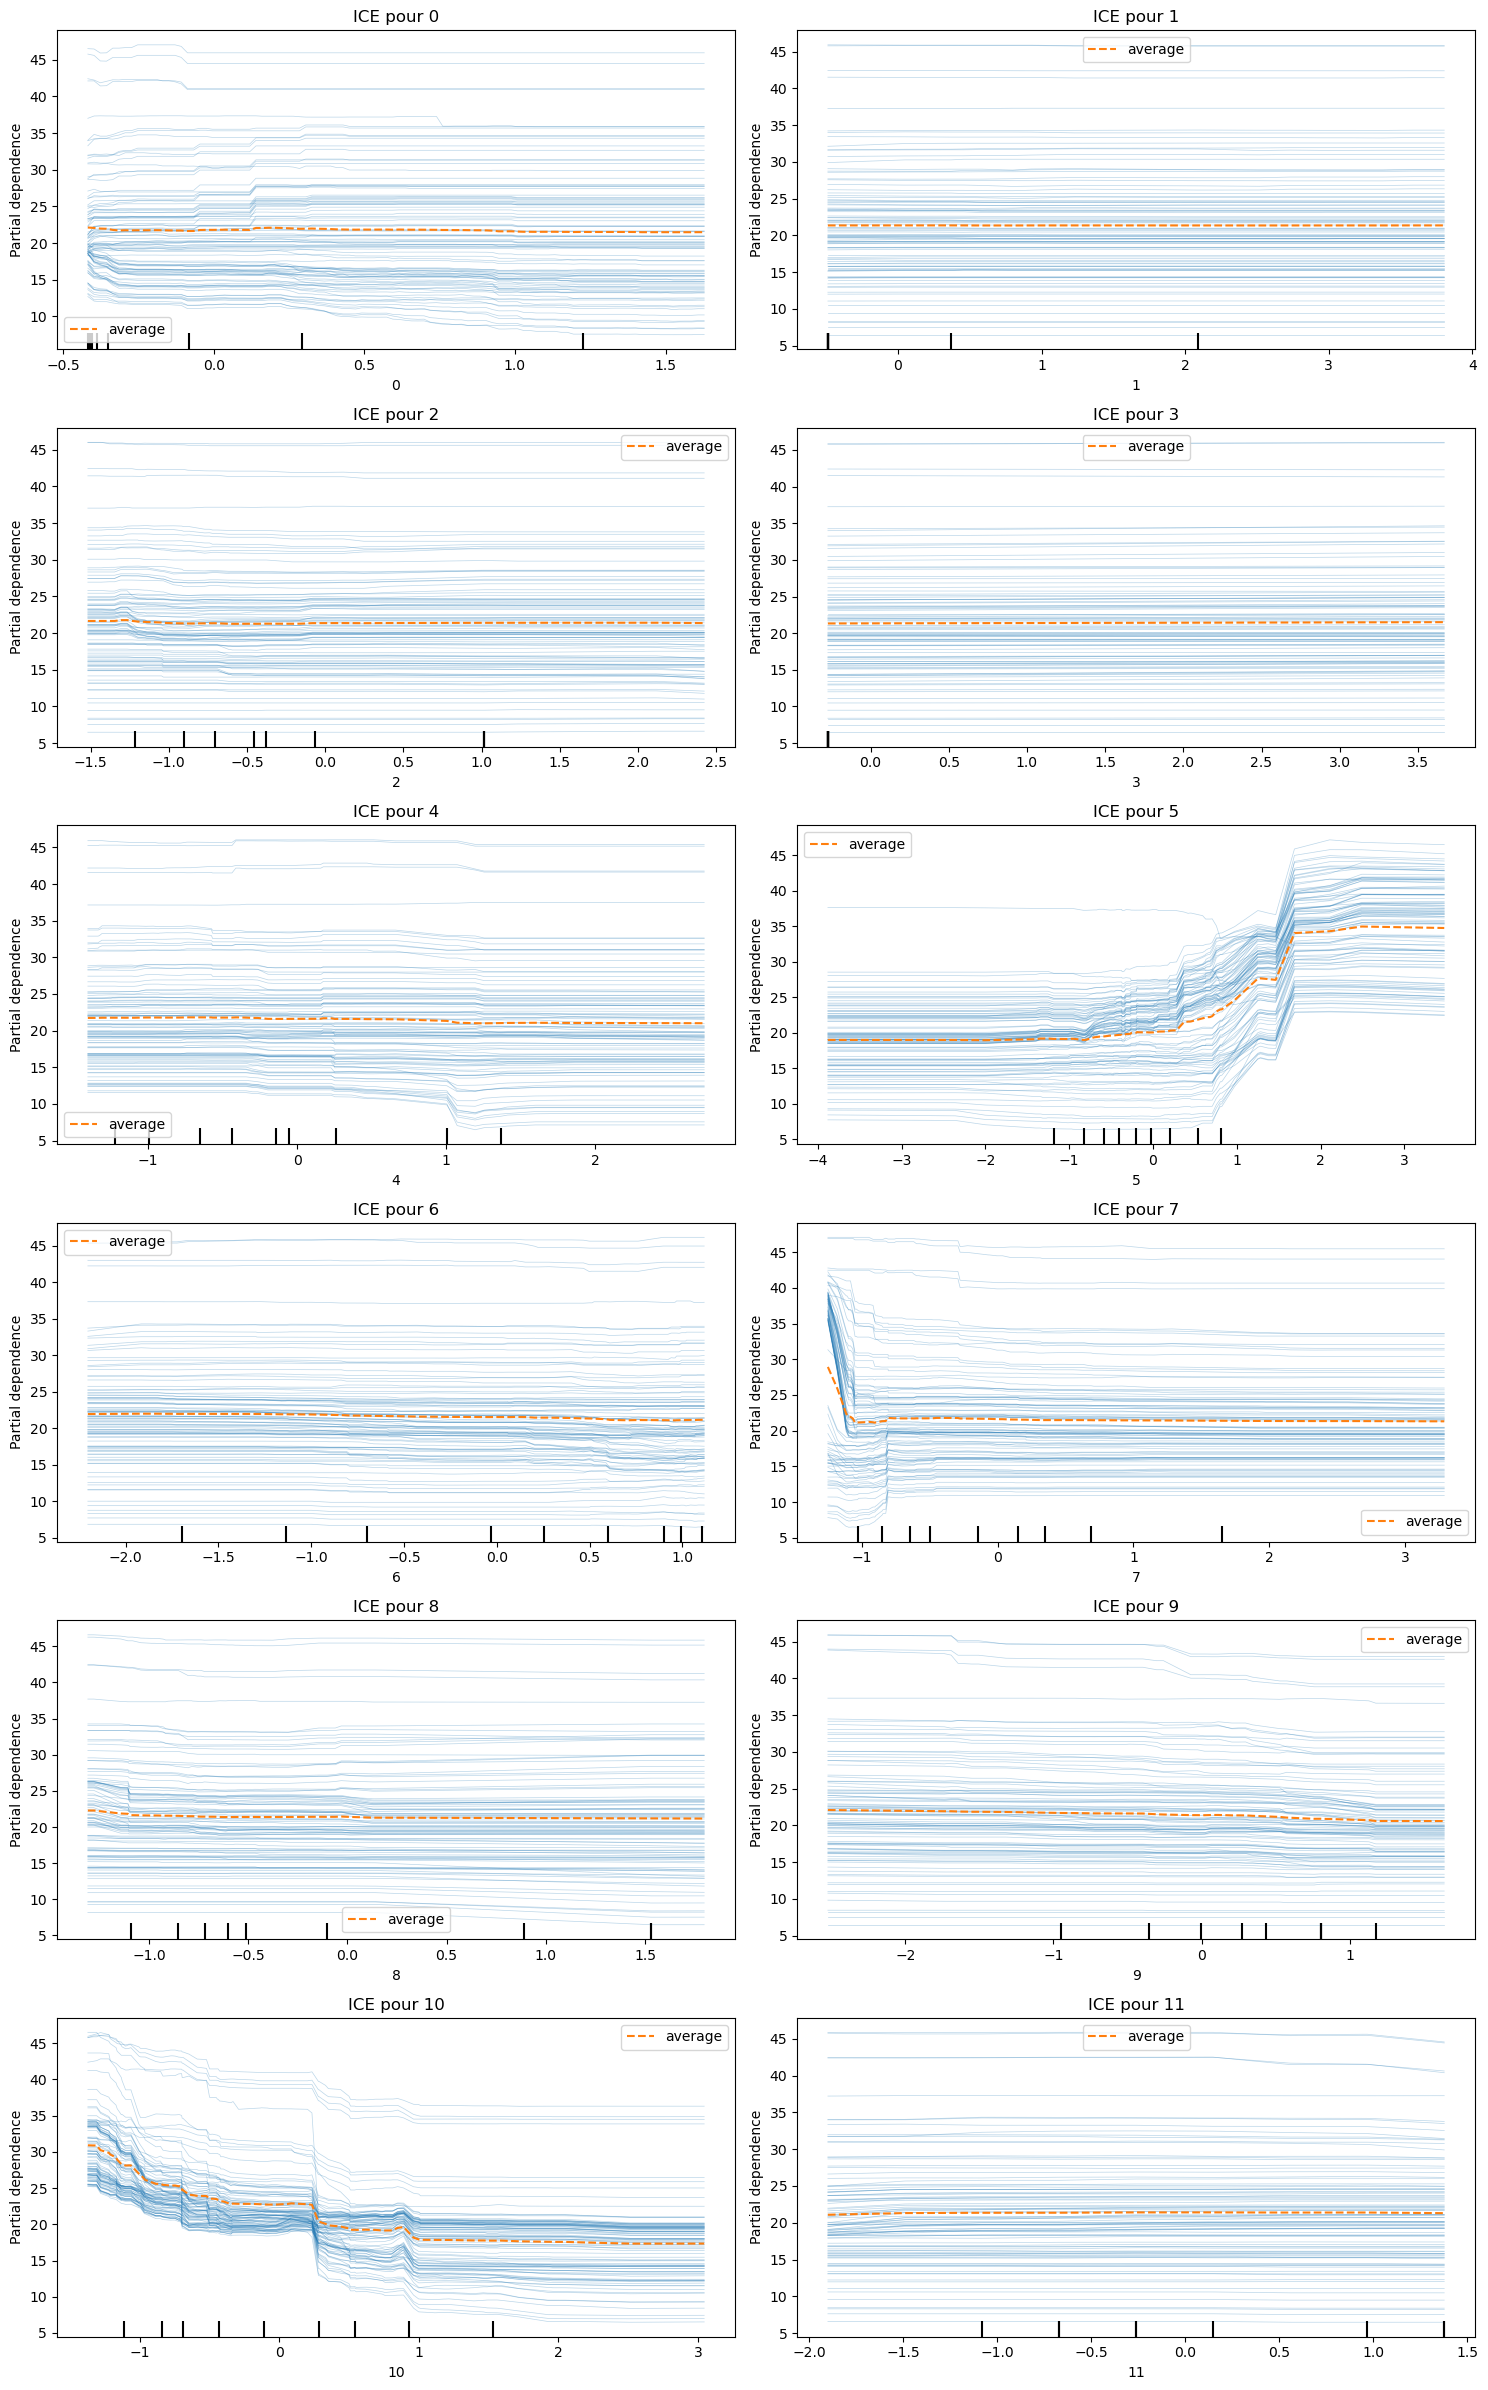

In [24]:
def plot_ice(model, X, feature_names=None, max_samples=100):
    """
    Trace les courbes ICE pour chaque caractéristique d'un jeu de données.
    
    Paramètres:
    - model : modèle ajusté (RandomForestRegressor)
    - X : matrice des caractéristiques (NumPy array ou DataFrame)
    - feature_names : liste optionnelle des noms de caractéristiques
    - max_samples : nombre maximal d'instances à tracer pour réduire le temps de calcul
    """
    # Convertir en DataFrame si c'est un NumPy array
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)
    
    # Récupérer les noms de colonnes réels
    actual_feature_names = list(X.columns)
    
    # Si des noms de caractéristiques sont fournis, vérifier leur validité
    if feature_names is not None:
        # Filtrer les noms de caractéristiques qui existent réellement
        valid_features = [f for f in feature_names if f in actual_feature_names]
        
        if not valid_features:
            print("Attention : Aucun des noms de caractéristiques fournis n'est valide.")
            print("Utilisation des noms de colonnes originaux.")
            feature_names = actual_feature_names
        else:
            feature_names = valid_features
    else:
        feature_names = actual_feature_names
    
    # Sous-échantillonnage si le jeu de données est trop grand
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        
        if len(X) > max_samples:
            indices = np.random.choice(len(X), max_samples, replace=False)
            X_subset = X.iloc[indices]
        else:
            X_subset = X
        
        # Créer une figure avec un sous-graphique pour chaque caractéristique
        n_features = len(feature_names)
        n_rows = (n_features + 1) // 2
        n_cols = min(2, n_features)
        
        fig, axes = plt.subplots(
            nrows=n_rows, 
            ncols=n_cols, 
            figsize=(15, 4 * n_rows)
        )
        
        # Ajuster les axes pour gérer différents nombres de caractéristiques
        if n_features == 1:
            axes = np.array([axes])
        else:
            axes = axes.ravel()
        
        # Tracer les courbes ICE pour chaque caractéristique
        for i, feature_name in enumerate(feature_names):
            PartialDependenceDisplay.from_estimator(
                estimator=model, 
                X=X_subset, 
                features=[feature_name], 
                ax=axes[i], 
                kind='both'
            )
            axes[i].set_title(f'ICE pour {feature_name}')
        
        # Supprimer les sous-graphiques supplémentaires s'il y en a
        for j in range(len(feature_names), len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout()
        plt.show()

# Exemple d'utilisation recommandé
# Assurez-vous d'avoir entraîné votre modèle avant
rf.fit(X_train, y_train)
plot_ice(rf, X_test)  # Sans spécifier de noms de caractéristiques
# OU
# plot_ice(rf, X_test, feature_names=['CRIM', 'autres colonnes'])

#### B) LIME (Model local pour expliquer une prédiction)

Intercept 24.423345537515985
Prediction_local [23.88794818]
Right: 23.392999999999994


<Figure size 1000x600 with 0 Axes>

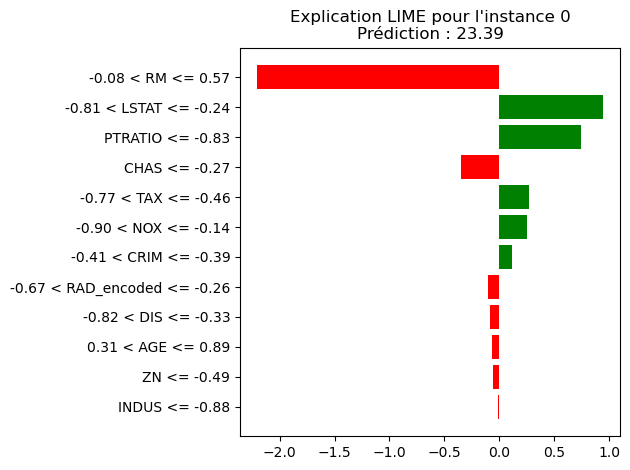


Explication détaillée :
Contribution des caractéristiques à la prédiction :


TypeError: list indices must be integers or slices, not str

In [25]:
# Masquer les avertissements
warnings.filterwarnings("ignore")

def explain_prediction_lime(model, X_train, X_test, feature_names, instance_index=0, class_names=None):
    """
    Explique une prédiction individuelle en utilisant LIME
    
    Paramètres:
    - model : modèle entraîné (RandomForestRegressor)
    - X_train : données d'entraînement (NumPy array ou DataFrame)
    - X_test : données de test (NumPy array ou DataFrame)
    - feature_names : noms des caractéristiques
    - instance_index : index de l'instance à expliquer
    - class_names : noms des classes (optionnel)
    """
    # Conversion en numpy si nécessaire
    X_train_array = X_train.values if hasattr(X_train, 'values') else X_train
    X_test_array = X_test.values if hasattr(X_test, 'values') else X_test
    
    # Sélectionner l'instance à expliquer
    instance = X_test_array[instance_index]
    
    # Créer l'explainer LIME
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=X_train_array,
        feature_names=feature_names,
        verbose=True,
        mode='regression'  # Utiliser 'regression' pour un problème de régression
    )
    
    # Prédiction du modèle pour cette instance
    prediction = model.predict(instance.reshape(1, -1))[0]
    
    # Générer l'explication locale
    explanation = explainer.explain_instance(
        data_row=instance, 
        predict_fn=model.predict,
        num_features=len(feature_names)
    )
    
    # Visualiser l'explication
    plt.figure(figsize=(10, 6))
    explanation.as_pyplot_figure()
    plt.title(f'Explication LIME pour l\'instance {instance_index}\nPrédiction : {prediction:.2f}')
    plt.tight_layout()
    plt.show()
    
    # Afficher les détails textuels de l'explication
    print("\nExplication détaillée :")
    print("Contribution des caractéristiques à la prédiction :")
    
    # Extraire et trier les contributions
    contributions = explanation.as_list()
    contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)
    
    for feature, contribution in contributions_sorted:
        print(f"{feature_names[feature]}: {contribution:.4f}")
    
    return explanation

# Exemple d'utilisation
lime_explanation = explain_prediction_lime(
    model=rf, 
    X_train=X_train, 
    X_test=X_test, 
    feature_names=X.columns.tolist()
)

# Restaurer le comportement par défaut des avertissements
warnings.filterwarnings("default")

#### C) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

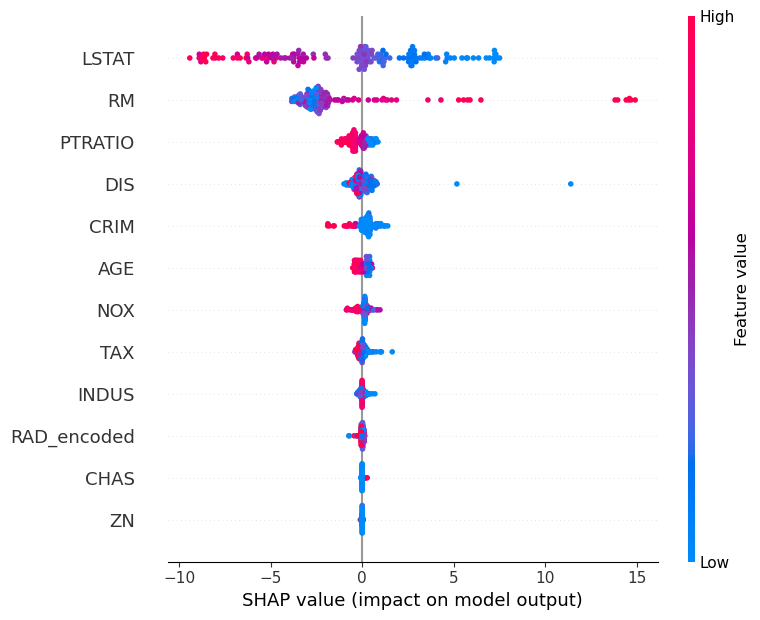

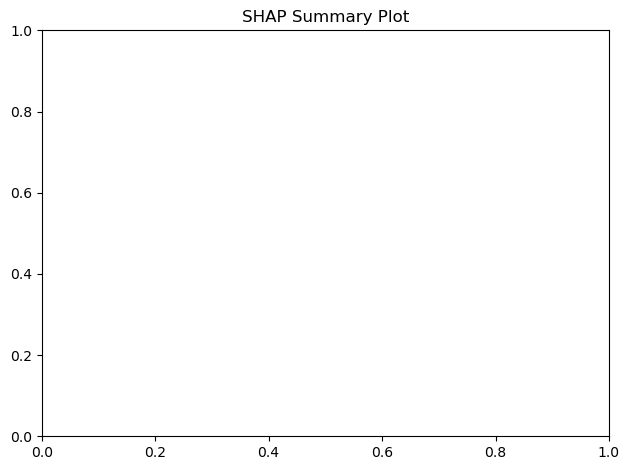

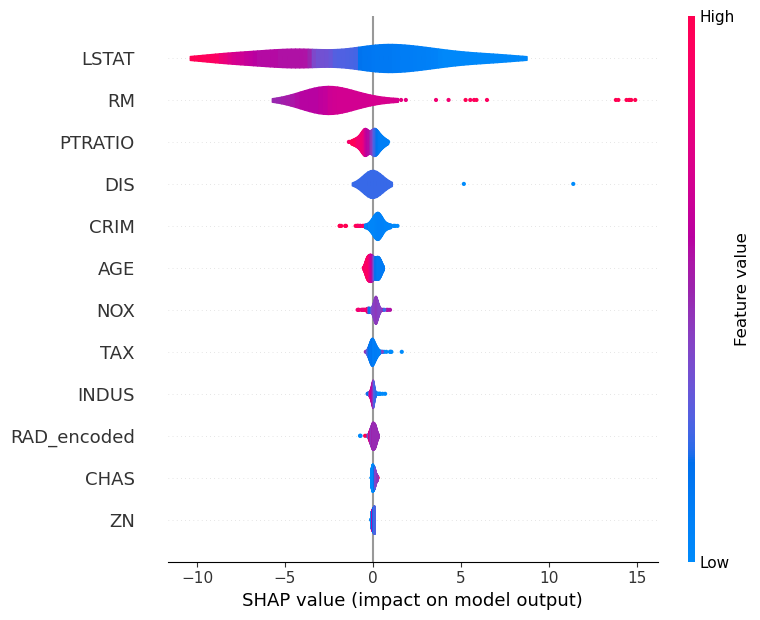

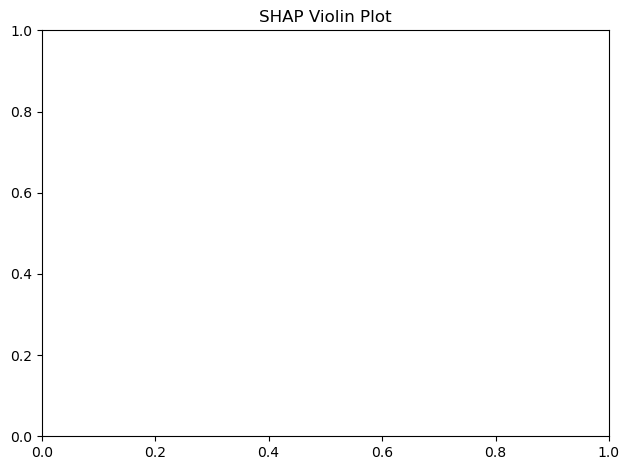

<Figure size 1000x600 with 0 Axes>

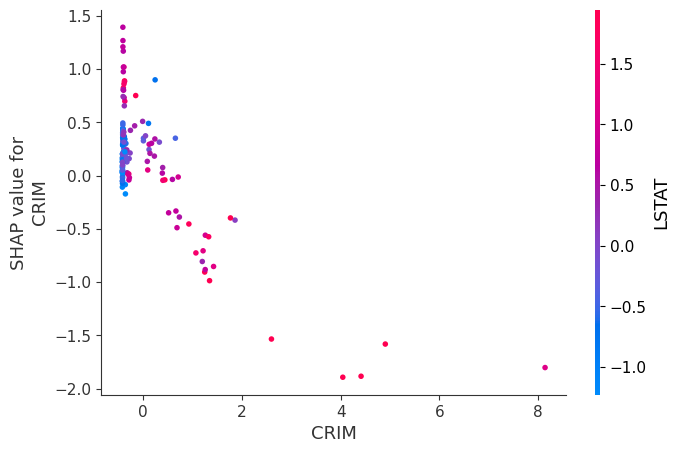

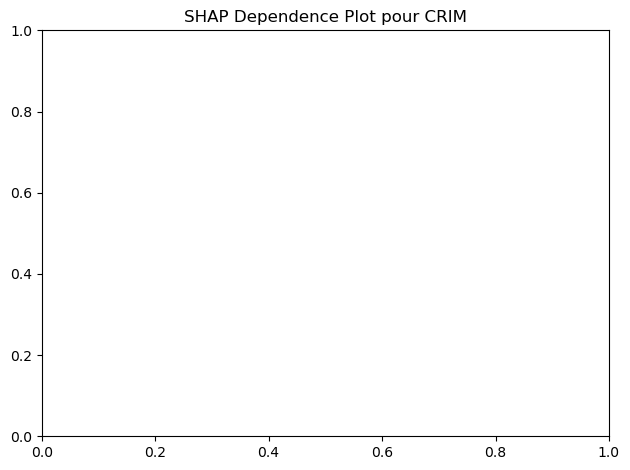

In [26]:
def plot_shap_summary(model, X, feature_names=None):
    """
    Génère plusieurs visualisations SHAP
    
    Paramètres:
    - model : modèle entraîné (RandomForestRegressor)
    - X : données de test (NumPy array ou DataFrame)
    - feature_names : noms des caractéristiques (optionnel)
    """
    # Conversion en numpy si nécessaire
    X_array = X.values if hasattr(X, 'values') else X
    
    # Noms des caractéristiques
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(X_array.shape[1])]
    
    # Créer l'explainer SHAP
    explainer = shap.TreeExplainer(model)
    
    # Calculer les valeurs SHAP
    shap_values = explainer.shap_values(X_array)
    
    # 1. Summary Plot (Bar Plot)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_array, feature_names=feature_names)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()
    
    # 2. Summary Plot (Violin Plot)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_array, plot_type="violin", feature_names=feature_names)
    plt.title('SHAP Violin Plot')
    plt.tight_layout()
    plt.show()
    
    # 3. Dependence Plot pour la première caractéristique
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(feature_names[0], shap_values, X_array, feature_names=feature_names)
    plt.title(f'SHAP Dependence Plot pour {feature_names[0]}')
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
plot_shap_summary(
    model=rf, 
    X=X_test, 
    feature_names=X.columns.tolist()
)

### 8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

#### A) BEESWARM

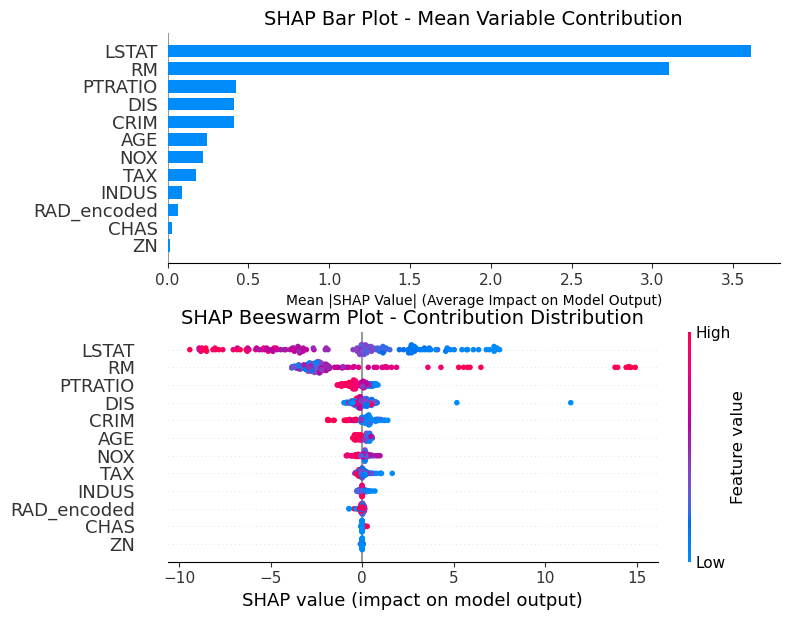

In [27]:
def plot_shap_beeswarm(model, X, feature_names=None):
    """
    Generates SHAP plots with improved layout and readability.
    
    Parameters:
    - model: Trained machine learning model
    - X: Input features
    - feature_names: Optional list of feature names
    """
    # Convert to numpy if necessary
    X_array = X.values if hasattr(X, 'values') else X
    
    # Set feature names if not provided
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(X_array.shape[1])]
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)
    
    # Calculate SHAP values
    shap_values = explainer.shap_values(X_array)
    
    # Create a figure with better spacing
    plt.figure(figsize=(16, 12))
    
    # Bar plot of mean SHAP values
    plt.subplot(2, 1, 1)
    shap.summary_plot(
        shap_values, 
        X_array, 
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title('SHAP Bar Plot - Mean Variable Contribution', fontsize=14)
    plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)', fontsize=10)
    
    # Beeswarm plot
    plt.subplot(2, 1, 2)
    shap.summary_plot(
        shap_values, 
        X_array, 
        feature_names=feature_names,
        show=False
    )
    plt.title('SHAP Beeswarm Plot - Contribution Distribution', fontsize=14)
    
    # Improve layout
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)  # Add more space between subplots
    plt.show()

# Usage example
rf.fit(X_train, y_train)
plot_shap_beeswarm(rf, X_test, feature_names=X.columns.tolist())

#### B) SCATTER

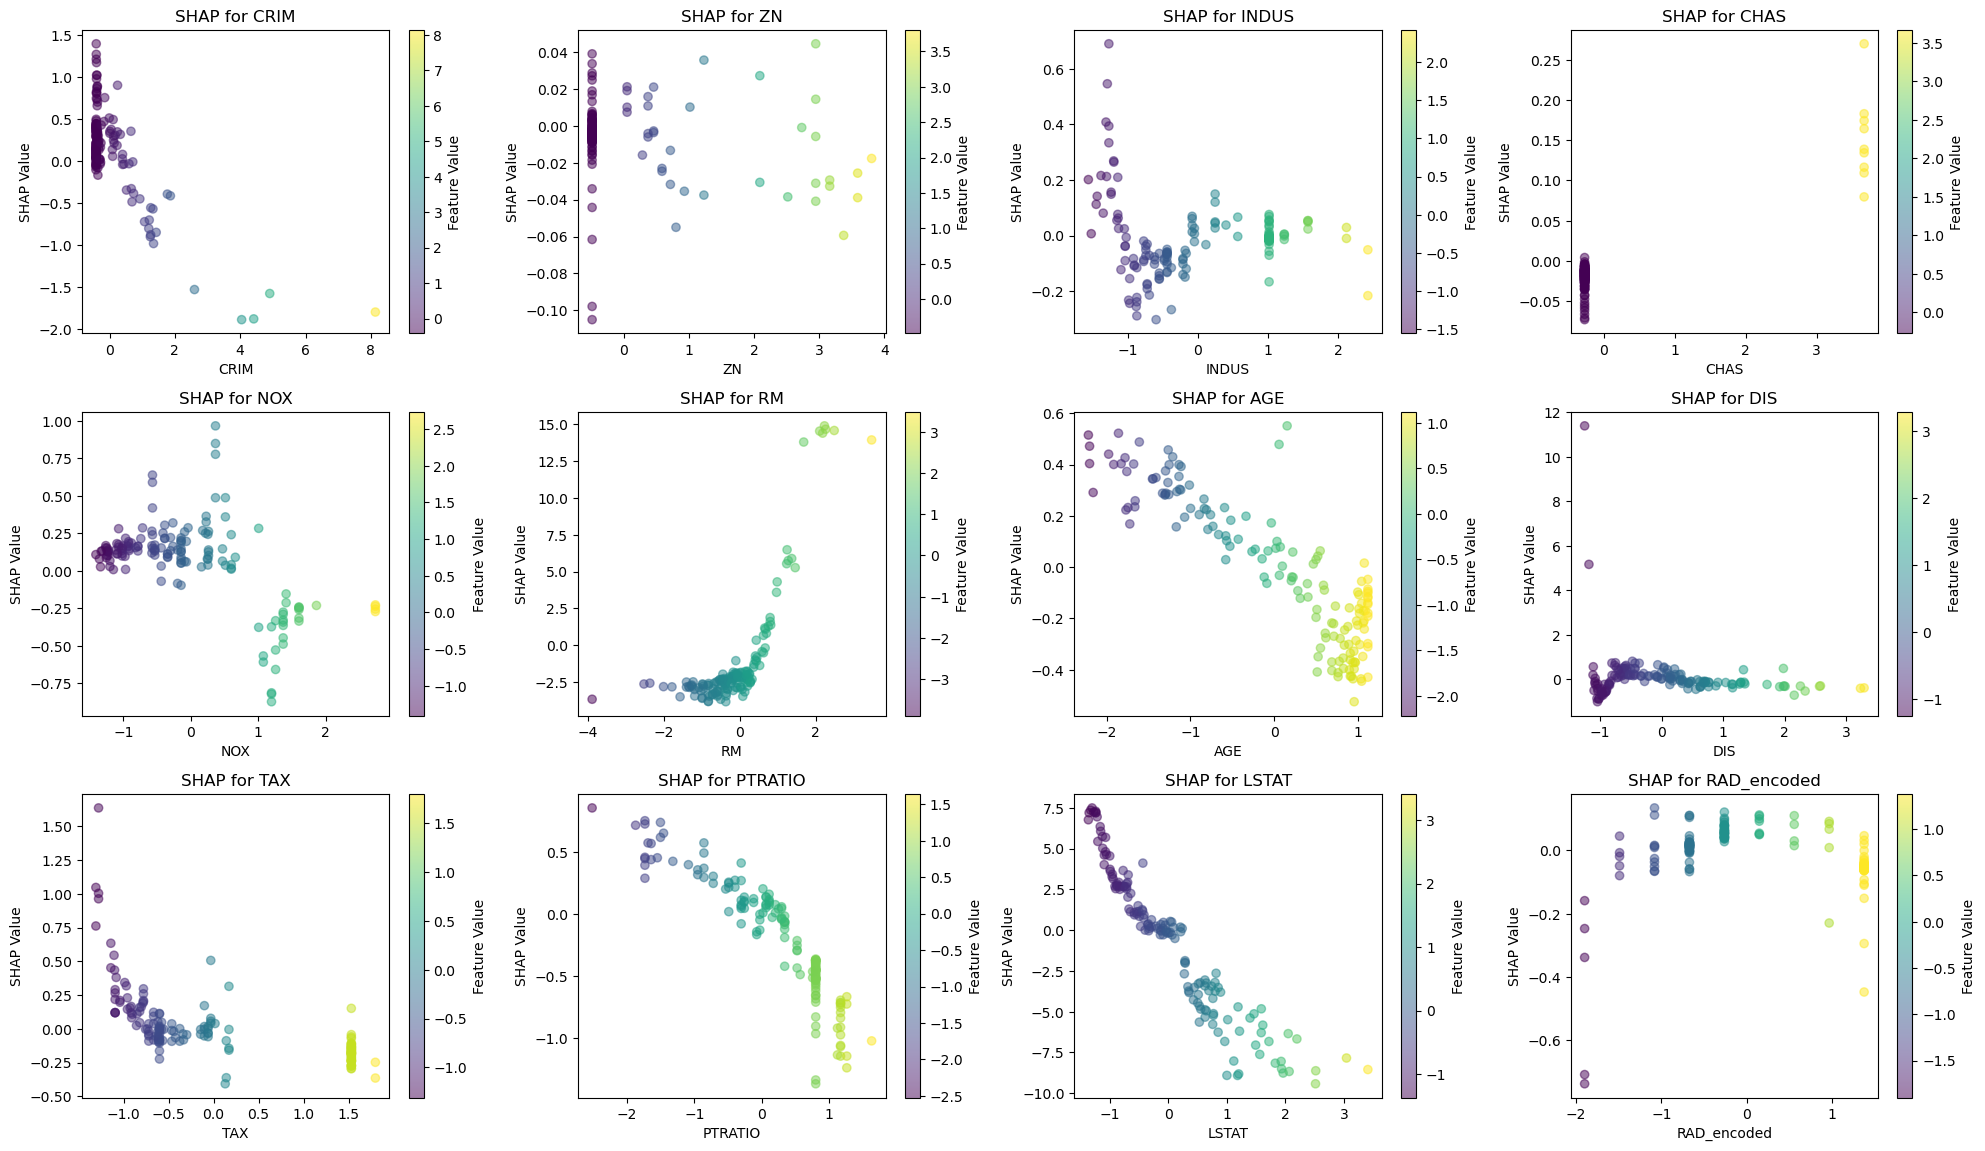

In [28]:
def plot_shap_scatter(model, X, feature_names=None):
    """
    Génère des scatter plots SHAP pour explorer l'impact des variables.
    
    Paramètres:
    - model: Modèle entraîné
    - X: Jeu de données
    - feature_names: Liste optionnelle des noms de caractéristiques
    """
    # Convertir en numpy si nécessaire
    X_array = X.values if hasattr(X, 'values') else X
    
    # Définir les noms de caractéristiques
    if feature_names is None:
        feature_names = [f'Feature {i}' for i in range(X_array.shape[1])]
    
    # Créer l'explainer SHAP
    explainer = shap.TreeExplainer(model)
    
    # Calculer les valeurs SHAP
    shap_values = explainer.shap_values(X_array)
    
    # Gérer différents formats de shap_values
    if isinstance(shap_values, list):
        # Pour les classifications multi-classes
        shap_values = shap_values[1]  # Généralement la classe positive
    
    # Créer une figure avec des subplots
    plt.figure(figsize=(20, 15))
    
    # Créer un scatter plot pour chaque feature
    for i, feature in enumerate(feature_names):
        plt.subplot(4, 4, i+1)
        
        # Scatter plot SHAP
        plt.scatter(
            X_array[:, i], 
            shap_values[:, i],  # Modification ici 
            alpha=0.5,
            c=X_array[:, i],  # Colorer par la valeur de la feature
            cmap='viridis'
        )
        
        plt.title(f'SHAP for {feature}')
        plt.xlabel(feature)
        plt.ylabel('SHAP Value')
        plt.colorbar(label='Feature Value')
    
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
plot_shap_scatter(rf, X_test, feature_names=X.columns.tolist())

# Conclusion